## Multi Variate

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

In [17]:
url = "https://raw.githubusercontent.com/gchandra10/filestorage/main/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

In [18]:
# 2) Select features and target
feature_cols = [
    "ENGINESIZE",
    "CYLINDERS",
    "FUELCONSUMPTION_CITY",
    "FUELCONSUMPTION_HWY",
    "FUELCONSUMPTION_COMB",
    "FUELCONSUMPTION_COMB_MPG",
]
target_col = "CO2EMISSIONS"

In [19]:
data = df[feature_cols + [target_col]].copy()

In [ ]:
# Optional quick check
print(data[feature_cols + [target_col]].describe())

In [20]:
X = data[feature_cols]
y = data[target_col]

In [21]:
# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

In [22]:
# 4) Build pipeline: impute -> scale -> linear regression
pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

In [23]:
# 5) Fit
pipe.fit(X_train, y_train)



,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [24]:
# 6) Predict and evaluate
y_pred = pipe.predict(X_test)


In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

MAE:  12.90
MSE:  399.42
RMSE: 19.99
R²:   0.903


In [26]:
# 7) Show coefficients per feature (after scaling)
lin = pipe.named_steps["model"]
scaler = pipe.named_steps["scaler"]

In [27]:
# In a Pipeline with scaling, coefficients correspond to scaled features.
# To get coefficients in original units, undo scaling effects:
coef_scaled = lin.coef_
coef_unscaled = coef_scaled / scaler.scale_
intercept_unscaled = lin.intercept_ - np.sum(coef_scaled * scaler.mean_ / scaler.scale_)

print("\nCoefficients (original feature scales):")
for name, c in zip(feature_cols, coef_unscaled):
    print(f"  {name:25s} {c:10.3f}")
print(f"Intercept: {intercept_unscaled:.3f}")


Coefficients (original feature scales):
  ENGINESIZE                     8.961
  CYLINDERS                      7.240
  FUELCONSUMPTION_CITY         -13.002
  FUELCONSUMPTION_HWY           -5.472
  FUELCONSUMPTION_COMB          21.867
  FUELCONSUMPTION_COMB_MPG      -4.034
Intercept: 262.572


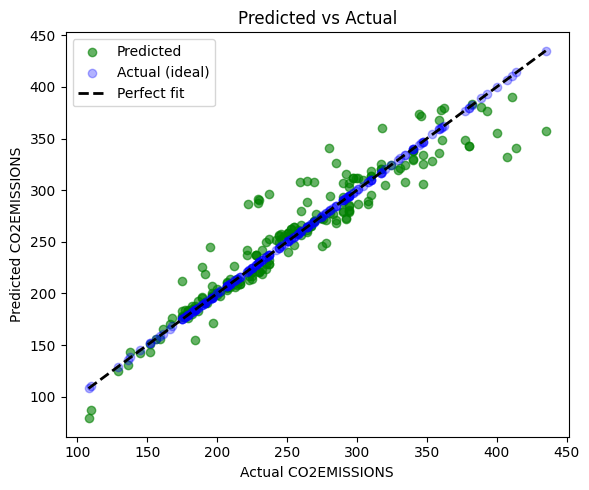

In [30]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color="green", alpha=0.6, label="Predicted")
plt.scatter(y_test, y_test, color="blue", alpha=0.3, label="Actual (ideal)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect fit")

plt.xlabel("Actual CO2EMISSIONS")
plt.ylabel("Predicted CO2EMISSIONS")
plt.title("Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()
